# Color String Art Playground

Set the image path and color palette, run all cells, and preview the reconstructed result.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matrix

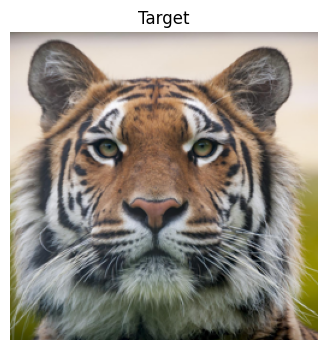

In [9]:
# --- Edit these settings ---
IMAGE_PATH = "images/tiger_3.jpg"
H = 256
P = 90
LINE_WIDTH = 0.3

# RGB thread palette: one [R, G, B] per thread color
COLORS = [
    [0, 0, 0],
    [144, 135, 6],
    [156, 114, 89],
]

target = Image.open(IMAGE_PATH).convert("RGB").resize((H, H))
target_np = np.array(target, dtype=np.uint8)

plt.figure(figsize=(4, 4))
plt.title("Target")
plt.imshow(target_np)
plt.axis("off")
plt.show()

In [10]:
# Build matrix + solve in color mode
M, solved = matrix.full_test(
    H,
    P,
    target_np,
    sparse=False,
    line_width=LINE_WIDTH,
    color=True,
    colors=COLORS,
)

print("M shape:", M.shape)
print("x shape:", solved.shape)

initializing matrix of size 262471680


100%|██████████| 90/90 [00:00<00:00, 313.58it/s]


M shape: (196608, 12015)
x shape: (12015,)


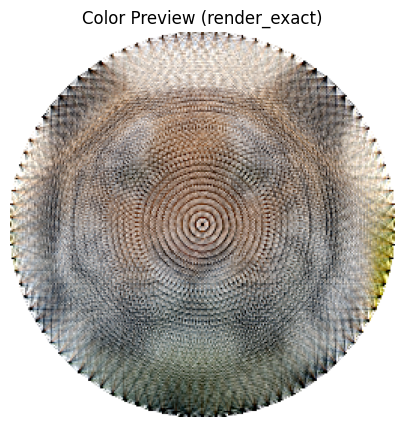

In [11]:
# Preview continuous least-squares reconstruction
preview_exact = matrix.render_exact(M, solved, H, color=True)

plt.figure(figsize=(5, 5))
plt.title("Color Preview (render_exact)")
plt.imshow(preview_exact)
plt.axis("off")
plt.show()

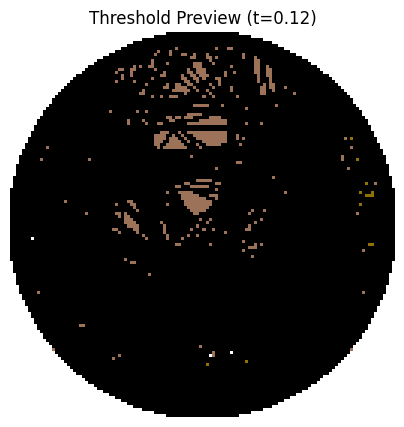

In [8]:
# Optional: thresholded line selection preview
THRESHOLD = 0.12
preview_threshold = matrix.render_image(
    M,
    solved,
    H,
    threshold=THRESHOLD,
    line_width=LINE_WIDTH,
    color=True,
    colors=COLORS,
)

plt.figure(figsize=(5, 5))
plt.title(f"Threshold Preview (t={THRESHOLD})")
plt.imshow(preview_threshold)
plt.axis("off")
plt.show()